### This file contains some test based on original AR Modeling file.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

from utils import data_loader_utils
from utils import user_defined_functions as udf


# Same as it shows in Decision_Tree.ipynb
DATA_ROOT = Path("./data")
OP = "OP07"
TRAIN_MACHINE = "M01"
TEST_MACHINES = ["M02", "M03"]

ORIGINAL_FS = 2000
TARGET_FS = 1000
WS = 4096   # the paper also indicates the same window length

P = 20  # AR order
TAU_Q = 0.99    # the threshold of M01 when its ok

In [2]:
def list_h5_files(machine, op, label):
    # label: "good" / "bad"
    folder = DATA_ROOT / machine / op / label
    return sorted(folder.glob("*.h5"))

def load_xyz(file_path):
    arr = data_loader_utils.datafile_read(file_path, False)
    return arr[:, :3]

# downsample to 1khz
def resample_xyz(xyz, fs_in=ORIGINAL_FS, fs_out=TARGET_FS):
    xs = udf.resample_milling_data(xyz[:,0], fs_in, fs_out)
    ys = udf.resample_milling_data(xyz[:,1], fs_in, fs_out)
    zs = udf.resample_milling_data(xyz[:,2], fs_in, fs_out)
    return np.stack([xs, ys, zs], axis=1)

# normalize every window (z-score)
def zscore_per_window(w, eps=1e-8):
    mu = w.mean(axis=0, keepdims=True)
    sd = w.std(axis=0, keepdims=True) + eps
    return (w - mu) / sd

def sliding_windows(xyz: np.ndarray, ws=WS):
    n = len(xyz)
    out = []
    for start in range(0, n - ws + 1, int(float(ws)/2)):
        out.append(xyz[start:start+ws])
    return out

In [3]:
train_ok_files = list_h5_files(TRAIN_MACHINE, OP, "good")
test_files = []
for m in TEST_MACHINES:
    test_files += [(m, "good", f) for f in list_h5_files(m, OP, "good")]
    test_files += [(m, "bad",  f) for f in list_h5_files(m, OP, "bad")]

print("Train OK files:", len(train_ok_files))
print("Test files:", len(test_files))

Train OK files: 43
Test files: 111


## Build Data
Only use good data for training, but test has both good and bad data

In [4]:
def build_windows_from_files(file_list, label_int=None):
    # label_int: if it's None then it's for training, otherwise for testing
    windows = []
    labels = []
    groups = []
    for fp in file_list:
        xyz = load_xyz(fp)
        xyz = resample_xyz(xyz)
        ws_list = sliding_windows(xyz, WS)
        for w in ws_list:
            w = zscore_per_window(w)
            windows.append(w)
            if label_int is not None:
                labels.append(label_int)
            groups.append(fp.name)
    if label_int is None:
        return windows, groups
    return windows, np.array(labels, dtype=int), groups

# Train windows, label_int = None by default
train_windows, train_groups = build_windows_from_files(train_ok_files)
print("Train windows:", len(train_windows))

# Test windows, for M02 and M03
test_windows = []
test_labels = []
test_groups = []
test_machines = []

for (m, lab, fp) in test_files:
    w_list, y_list, g_list = build_windows_from_files([fp], label_int=(0 if lab=="good" else 1))
    test_windows += w_list
    test_labels += list(y_list)
    test_groups += g_list
    test_machines += [m]*len(w_list)

test_labels = np.array(test_labels, dtype=int)
print("Test windows:", len(test_windows), "Bad data ratio:", test_labels.mean())


Train windows: 473
Test windows: 1180 Bad data ratio: 0.03728813559322034


## Build AR model

In [5]:
def fit_ar_coeffs(x, p: int):
    """
    Find coefficiency
    x: 1D array
    return: coeffs a shape=(p,)
    """
    x = np.asarray(x).astype(float)
    y = x[p:]
    Phi = np.column_stack([x[p-k-1:-(k+1)] for k in range(p)])  # t-1..t-p
    # y = Phi @ a
    a, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    return a

def concat_axis(train_windows, axis_idx: int):
    return np.concatenate([w[:, axis_idx] for w in train_windows], axis=0)

# For 3 axis
a_x = fit_ar_coeffs(concat_axis(train_windows, 0), P)
a_y = fit_ar_coeffs(concat_axis(train_windows, 1), P)
a_z = fit_ar_coeffs(concat_axis(train_windows, 2), P)
# Shape: (P,)

tau = 1.0090873128921258


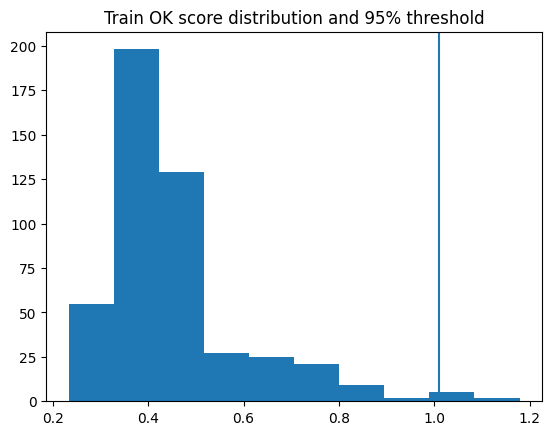

In [6]:
def ar_residual_mse(x, a):
    """
    x: 1D window
    a: AR coefficient (p,)
    return: mean squared residual
    """
    p = len(a)
    x = np.asarray(x).astype(float)
    if len(x) <= p: # if length of window not enough for prediction return Nan
        return np.nan
    # xhat[t] = sum_{k=1..p} a[k-1] * x[t-k]
    y = x[p:]
    Phi = np.column_stack([x[p-k-1:-(k+1)] for k in range(p)])
    yhat = Phi @ a
    r = y - yhat
    return float(np.mean(r**2))

def window_score(w):
    sx = ar_residual_mse(w[:,0], a_x)
    sy = ar_residual_mse(w[:,1], a_y)
    sz = ar_residual_mse(w[:,2], a_z)
    return sx + sy + sz

train_scores = np.array([window_score(w) for w in train_windows], dtype=float)
train_scores = train_scores[np.isfinite(train_scores)]  # exclude all the Nans

tau = np.quantile(train_scores, TAU_Q)
print("tau =", tau) # 95%

plt.figure()
plt.hist(train_scores)
plt.axvline(tau)
plt.title("Train OK score distribution and 95% threshold")
plt.show()


In [7]:
test_scores = np.array([window_score(w) for w in test_windows], dtype=float)
pred = (test_scores > tau).astype(int)  # 1=NOK, 0=OK

print("Accuracy:", accuracy_score(test_labels, pred))
print("F1:", f1_score(test_labels, pred))
print(confusion_matrix(test_labels, pred))


Accuracy: 0.9194915254237288
F1: 0.4808743169398907
[[1041   95]
 [   0   44]]


The confusion matrix above shows a very good result, it shows no missing detections (NOK recall=1).

## The Following parts are for testing


#### Test1 
#### In this part I divide each window into 3 phases, with early&late phases take 20% of the window length.


In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Split each window into early / mid / late phases based on time order
def phase_index(n, early_frac=0.2, late_frac=0.2):
    idx = np.full(n, 1, dtype=int)  # 0=early, 1=mid, 2=late
    e = int(np.floor(early_frac * n))
    l = int(np.floor((1.0 - late_frac) * n))
    idx[:e] = 0
    idx[l:] = 2
    return idx

# Compute confusion-matrix counts per phase
def counts_by_phase(y_true, y_pred, phase_ids):
    out = {}
    for pid, name in [(0, "early"), (1, "mid"), (2, "late")]:
        m = (phase_ids == pid)
        cm = confusion_matrix(y_true[m], y_pred[m], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        out[name] = {
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "n": int(np.sum(m))
        }
    return out


In [22]:
def print_phase_report(rep):
    total_fp = sum(v["FP"] for v in rep.values())
    total_fn = sum(v["FN"] for v in rep.values())

    print(f"Total FP={total_fp}, Total FN={total_fn}")

    for name in ["early", "mid", "late"]:
        v = rep[name]

        fp_share = (v["FP"] / total_fp) if total_fp > 0 else 0.0
        fn_share = (v["FN"] / total_fn) if total_fn > 0 else 0.0
        fp_percent_in_phase = (v["FP"] / v["n"]) if v["n"] > 0 else 0.0

        print(
            f"{name}: n={v['n']}, TN={v['TN']}, FP={v['FP']}, "
            f"FN={v['FN']}, TP={v['TP']}, "
            f"FP_share={fp_share:.3f}, "
            f"FP_percent_in_phase={fp_percent_in_phase:.3f}, "
            f"FN_share={fn_share:.3f}"
        )


In [23]:
# Phase assignment for all test windows
phase_ids = phase_index(len(test_windows), early_frac=0.2, late_frac=0.2)

# Phase-wise evaluation on all windows
rep_all = counts_by_phase(
    np.asarray(test_labels),
    np.asarray(pred),
    phase_ids
)

print("\n=== Phase breakdown  ===")
print_phase_report(rep_all)

# Additional evaluation restricted to mid-phase windows
mid_mask = (phase_ids == 1)
y_true_midonly = np.asarray(test_labels)[mid_mask]
scores_mid = np.asarray(test_scores)[mid_mask]
pred_midonly = (scores_mid > tau).astype(int)

cm_midonly = confusion_matrix(y_true_midonly, pred_midonly, labels=[0, 1])
tn, fp, fn, tp = cm_midonly.ravel()





=== Phase breakdown  ===
Total FP=95, Total FN=0
early: n=236, TN=234, FP=2, FN=0, TP=0, FP_share=0.021, FP_percent_in_phase=0.008, FN_share=0.000
mid: n=708, TN=634, FP=51, FN=0, TP=23, FP_share=0.537, FP_percent_in_phase=0.072, FN_share=0.000
late: n=236, TN=173, FP=42, FN=0, TP=21, FP_share=0.442, FP_percent_in_phase=0.178, FN_share=0.000


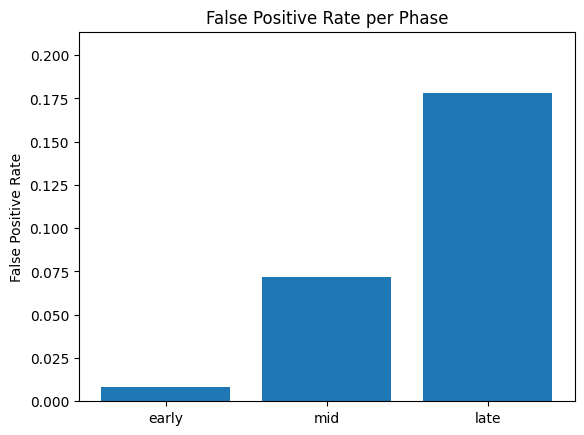

In [24]:
import matplotlib.pyplot as plt

phases = ["early", "mid", "late"]
fp_rates = [
    rep_all["early"]["FP"] / rep_all["early"]["n"],
    rep_all["mid"]["FP"] / rep_all["mid"]["n"],
    rep_all["late"]["FP"] / rep_all["late"]["n"],
]

plt.figure()
plt.bar(phases, fp_rates)
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate per Phase")
plt.ylim(0, max(fp_rates) * 1.2)
plt.show()


### Result
#### While the mid phase contains the largest number of windows and therefore more false positives in total, the probability of a healthy window being misclassified is actually higher in the late phase
#### This provides insight into how classification errors evolve over the operation, showing that false positives are phase-dependent rather than uniformly distributed.

### Test2


In [34]:
# ============================================================
# AR order sensitivity analysis 
# ============================================================

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

P_list = [5, 10, 15, 20, 25, 30, 40]
results_ar_order = []

for p_test in P_list:
    # --- Refit AR coefficients
    a_x_test = fit_ar_coeffs(concat_axis(train_windows, 0), p_test)
    a_y_test = fit_ar_coeffs(concat_axis(train_windows, 1), p_test)
    a_z_test = fit_ar_coeffs(concat_axis(train_windows, 2), p_test)

    #  Define score function
    def window_score_p(w):
        sx = ar_residual_mse(w[:, 0], a_x_test)
        sy = ar_residual_mse(w[:, 1], a_y_test)
        sz = ar_residual_mse(w[:, 2], a_z_test)
        return sx + sy + sz

    #  Threshold from training OK windows 
    train_scores_p = np.array([window_score_p(w) for w in train_windows], dtype=float)
    train_scores_p = train_scores_p[np.isfinite(train_scores_p)]
    tau_p = np.quantile(train_scores_p, TAU_Q)

    #  Evaluate on test windows 
    test_scores_p = np.array([window_score_p(w) for w in test_windows], dtype=float)
    pred_p = (test_scores_p > tau_p).astype(int)

    tn, fp, fn, tp = confusion_matrix(test_labels, pred_p, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    results_ar_order.append({
        "P": p_test,
        "tau": tau_p,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "ACC": accuracy_score(test_labels, pred_p),
        "F1": f1_score(test_labels, pred_p)
    })

#  Print results
header = "P   tau     FPR     ACC     F1    FP  FN"
print(header)
print("-" * len(header))
for r in results_ar_order:
    print(
        f"{r['P']:>2d}  {r['tau']:<7.3f} {r['FPR']:<7.3f} "
        f"{r['ACC']:<7.3f} {r['F1']:<7.3f} {r['FP']:>3d} {r['FN']:>3d}"
    )


P   tau     FPR     ACC     F1    FP  FN
----------------------------------------
 5  1.030   0.180   0.826   0.300   205   0
10  1.053   0.098   0.906   0.442   111   0
15  1.030   0.090   0.914   0.463   102   0
20  1.009   0.084   0.919   0.481    95   0
25  0.976   0.097   0.907   0.444   110   0
30  0.953   0.107   0.897   0.421   121   0
40  0.938   0.118   0.886   0.396   134   0


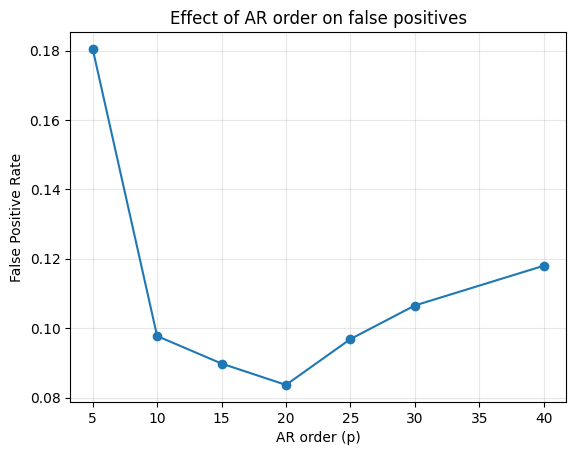

In [35]:
import matplotlib.pyplot as plt

P_vals = [r["P"] for r in results_ar_order]
FPR_vals = [r["FPR"] for r in results_ar_order]

plt.figure()
plt.plot(P_vals, FPR_vals, marker="o")
plt.xlabel("AR order (p)")
plt.ylabel("False Positive Rate")
plt.title("Effect of AR order on false positives")
plt.grid(True, alpha=0.3)
plt.show()


### The false positive rate decreases with increasing AR order due to reduced underfitting, reaches a minimum around 𝑝 = 20, and increases again for larger orders, indicating a trade-off between model complexity and cross-machine generalization.